#Capstone 3: Predicting iPSC Donor Differentiation Success

I this project we will use iPSC scRNA-seq data from a dataset of 125 donors to predict endoderm differntiation efficiency. This dataset if from the publication

Cuomo, A.S.E., Seaton, D.D., McCarthy, D.J. *et al.*  
**Single-cell RNA-sequencing of differentiating iPS cells reveals dynamic genetic effects on gene expression.**  
*Nature Communications*, 11, 810 (2020).  
https://doi.org/10.1038/s41467-020-14457-z

The dataset can be dowloaded at: https://zenodo.org/record/3625024#.Xil-0y2cZ0s

The code used in this original publication can be found on Github: https://github.com/single-cell-genetics/singlecell_endodiff_paper/tree/main

##Loading Data

In this notebook we will build a predictive model using the scRNAseq counts from day0 cells (aka iPSCs prior to any differentiation) to predict the definitive endoderm (DE) score. This data can be found in the .h5ad file generated in the previous EDA notebook for this project and stored in the Google Drive foler Capstone3_iPSC_EDA.  There are two different DE scores that can be used as the target label, each with it's own dataset.

DEscore = Score derived from high expression of genes associated with endogenous definitive endoderm cells and low expression of genes associated with iPSCs, made using the `score_genes` function in the ScanPy library.

psuedorank = Score derived from the `psuedotime`, function in the ScanPy library which generates a progression from a randomly chosen day0 cell through the most differentiated cell in the dataset.

We'll start with mounting Google Drive, installing and importing the necessary libraries and loading the data files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [ ]:
!pip install scanpy anndata seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.6 MB/s eta 0:00:00


In [ ]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 21.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, kendalltau
import shap
from collections import Counter
from catboost import Pool

In [ ]:
day0_score = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/Capstone3_iPSC_EDA/adata_DEscores_day0.h5ad")

##Convert Day0 data to Pseudobulk

As was shown in the previous notebook, building a predictive model from single cell data was not successfull as the learners focused on the noise in the data.  To address this, we will convert the data to psuedobulk with each donor being one sample.  The standard protocol is to sum the raw counts for each cell from a given donor.

In [ ]:
#Code from https://www.youtube.com/watch?v=Ee0PQUwVH8Q
donors = []
for donor in day0_score.obs["donor"].unique():
  donor_day0 = day0_score[day0_score.obs["donor"] == donor].copy()
  donor_day0.X = donor_day0.layers["counts"] #Access the saved raw counts
  donor_rep = sc.AnnData(X = donor_day0.X.sum(axis=0).reshape(1, -1), var = donor_day0.var)
  donor_rep.obs_names = [donor]
  donor_rep.obs['DEscore_long'] = donor_day0.obs['mean_DEscore_long'].iloc[0]  #use our previously creates average scores from the day3 cells
  donor_rep.obs['DEscore_short'] = donor_day0.obs['mean_DEscore_short'].iloc[0]
  donor_rep.obs['pseudorank'] = donor_day0.obs['mean_pseudorank'].iloc[0]
  donors.append(donor_rep)
donor_adata = sc.concat(donors)

In [ ]:
#Verify our new dataset has the expected shape and columns
donor_adata

AnnData object with n_obs × n_vars = 92 × 11231
    obs: 'DEscore_long', 'DEscore_short', 'pseudorank'

In [ ]:
#Normalize pseudobulk data
donor_adata.layers['counts'] = donor_adata.X.copy() #Stores raw counts in layer of the adata object so they're not lost during normalization
sc.pp.normalize_total(donor_adata, target_sum=1e4) #Normalize counts
sc.pp.log1p(donor_adata)

##Dimension Reduction

Our current dataset includes counts from about 11,000 genes.  To reduce this to a manageable amount for screening models, we will take the top 100 genes with the greatest correlation to DE Score or pseudorank


PCs don't seem to drastically correlate with DE score, based on looking at the color patterns.  Pseudotime score (aka pseudoranks) correlate with PCs a little better, but still not what we were hoping for.

Next, we will finding the genes that correlate with DE score (or psuedorank) the best. Hint: these are most likely not the most variable genes.

In [ ]:
# Find genes that correlate with DE scores.
y = donor_adata.obs['DEscore_long'].values
corrs = []
for g in donor_adata.var_names:
  x = donor_adata[:, g].X.flatten()
  r, _ = spearmanr(x,y)
  corrs.append(r)
donor_adata.var['corr_DE'] = corrs

In [ ]:
# Find genes that correlate with pseudoranks.
y = donor_adata.obs['pseudorank'].values
corrs = []
for g in donor_adata.var_names:
  x = donor_adata[:, g].X.flatten()
  r, _ = spearmanr(x,y)
  corrs.append(r)
donor_adata.var['corr_PR'] = corrs

In [ ]:
#Sort donor_adata based on correlation to DE score, collect the 100 genes with the highest correlations
top_genes_score = donor_adata.var['corr_DE'].abs().sort_values(ascending=False).head(100).index

#Sort donor_adata based on correlation to pseudorank, collect the 100 genes with the highest correlations
top_genes_rank = donor_adata.var['corr_PR'].abs().sort_values(ascending=False).head(100).index

#Make new scanpy datasets with only the 100 selected genes correlating with DE_score and pseudorank, respectively
donor_score = donor_adata[:, top_genes_score].copy()
donor_rank = donor_adata[:, top_genes_rank].copy()

##Model Building: Screening Learners

I will test the data set of 100 genes with regressors, using a tree based approach.

We will try using the 100 individual genes with the greatest correlations with DE score, as this model would remove the necessity of RNAseq to produce future datasets. These datasets are already saved as `donor_score` and `donor_rank`, respectively.

We can start with train, test splits on our final datasets.

Model screening will start with DE score and then we'll test the best learners with pseudorank predictions.

In [ ]:
#For correlating genes, predicting DE score
X = pd.DataFrame(donor_score.X, columns=donor_score.var_names, index=donor_score.obs_names)
y = donor_score.obs['DEscore_long']

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(X, y, test_size=0.2, random_state=12)

In [ ]:
#For correlating genes, predicting pseudorank
X = pd.DataFrame(donor_rank.X, columns=donor_rank.var_names, index=donor_rank.obs_names)
y = donor_rank.obs['pseudorank']

X_train_rank, X_test_rank, y_train_rank, y_test_rank = train_test_split(X, y, test_size=0.2, random_state=12)

####Predicting DE Score

In [ ]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_score, y_train_score)
RF.score(X_train_score, y_train_score)

0.9225038156835401

In [ ]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_score))
y_pred_RF_score_genes = np.array(RF.predict(X_test_score))
mae_RF = mean_absolute_error(y_test_score, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_score, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.5026065352912271


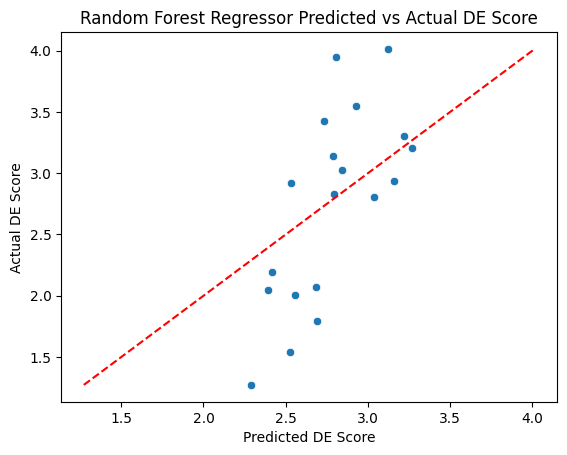

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Random Forest Regressor Predicted vs Actual DE Score')
plt.show()

In [ ]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_score, y_train_score)
GB.score(X_train_score, y_train_score)

0.9999454607607309

In [ ]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_score))
mae_GB = mean_absolute_error(y_test_score, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_score, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.5442397335083209


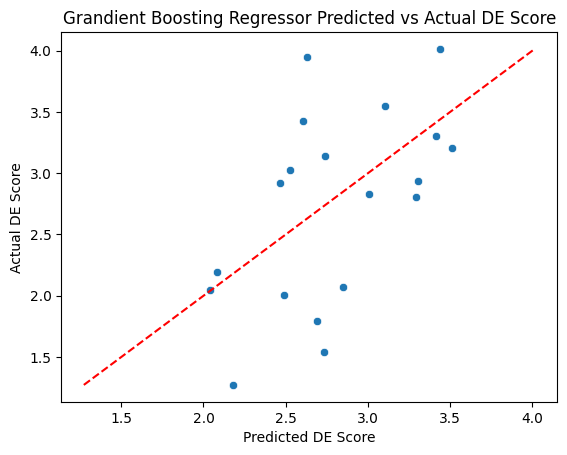

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Grandient Boosting Regressor Predicted vs Actual DE Score')
plt.show()

In [ ]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_score, y_train_score)
XG.score(X_train_score, y_train_score)

0.9999995376794434

In [ ]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_score))
mae_XG = mean_absolute_error(y_test_score, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_score, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.5381272424669837


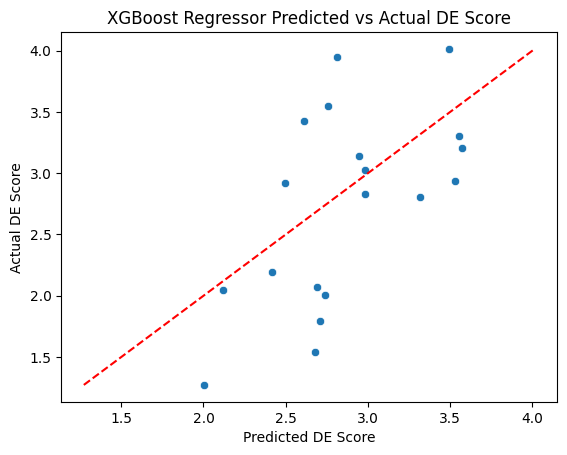

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('XGBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [ ]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor(verbose=0)
CB.fit(X_train_score, y_train_score)
CB.score(X_train_score, y_train_score)

np.float64(0.9999996567926562)

In [ ]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_score))
y_pred_CB_score_genes = np.array(CB.predict(X_test_score))
mae_CB = mean_absolute_error(y_test_score, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_score, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.4958867072369231


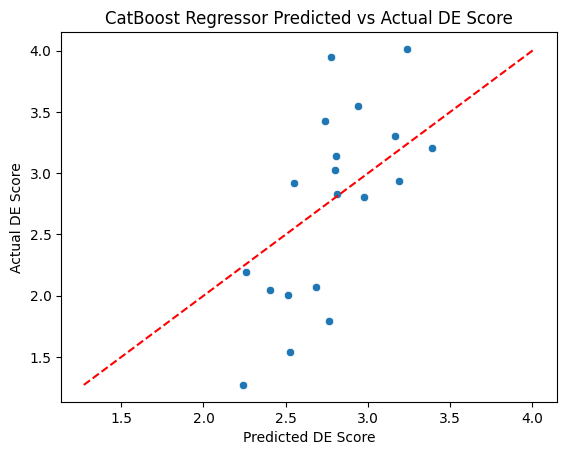

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('CatBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [ ]:
MAE_dict = {'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Random Forest Regressor': RF.score(X_train_score, y_train_score), 'Gradient Boost Regressor': GB.score(X_train_score, y_train_score),
                 'XGBoost Regressor': XG.score(X_train_score, y_train_score), 'CatBoost Regressor': CB.score(X_train_score, y_train_score)}
summary_genes_score = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_genes_score

,MAE,MAPE,R²
Random Forest Regressor,0.502607,0.220917,0.922504
Gradient Boost Regressor,0.544240,0.233837,0.999945
XGBoost Regressor,0.538127,0.229096,1.000000
CatBoost Regressor,0.495887,0.217116,1.000000


####Predicting Pseudorank

In [ ]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_rank, y_train_rank)
RF.score(X_train_rank, y_train_rank)

0.9327457876833324

In [ ]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_rank))
y_pred_RF_rank_genes = np.array(RF.predict(X_test_rank))
mae_RF = mean_absolute_error(y_test_rank, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_rank, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.016534989884025183


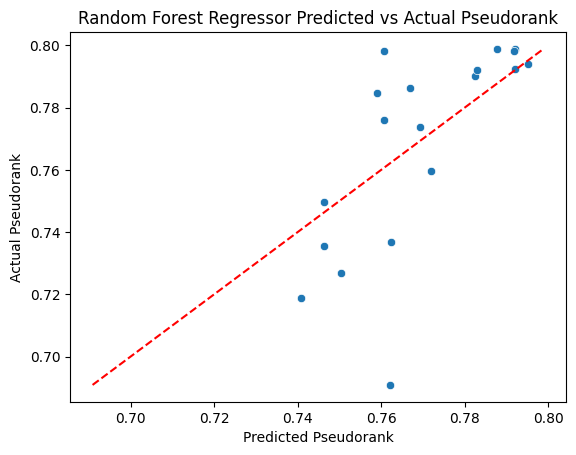

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Random Forest Regressor Predicted vs Actual Pseudorank')
plt.show()

In [ ]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_rank, y_train_rank)
GB.score(X_train_rank, y_train_rank)

0.9999735882740347

In [ ]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_rank))
mae_GB = mean_absolute_error(y_test_rank, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_rank, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.017312238573267757


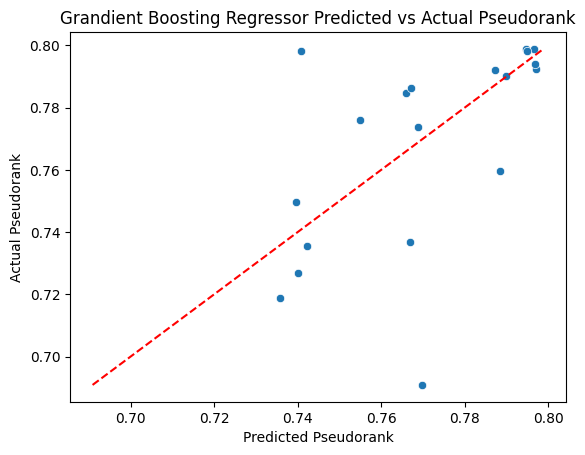

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Grandient Boosting Regressor Predicted vs Actual Pseudorank')
plt.show()

In [ ]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_rank, y_train_rank)
XG.score(X_train_rank, y_train_rank)

0.999701201915741

In [ ]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_rank))
mae_XG = mean_absolute_error(y_test_rank, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_rank, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.016227254644036293


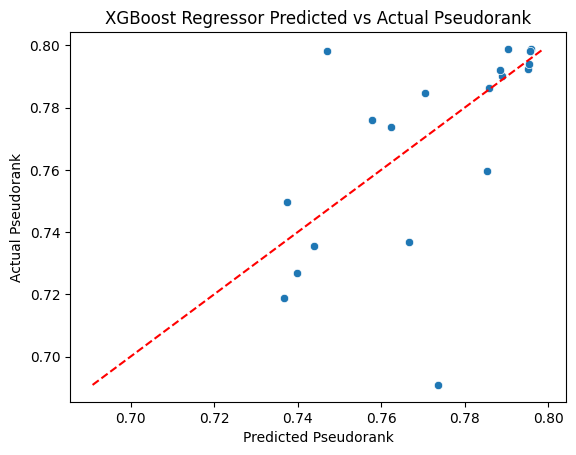

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('XGBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [ ]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor(verbose=0)
CB.fit(X_train_rank, y_train_rank)
CB.score(X_train_rank, y_train_rank)

np.float64(0.9999992088195696)

In [ ]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_rank))
y_pred_CB_rank_genes = np.array(CB.predict(X_test_rank))
mae_CB = mean_absolute_error(y_test_rank, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_rank, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.015454971064300044


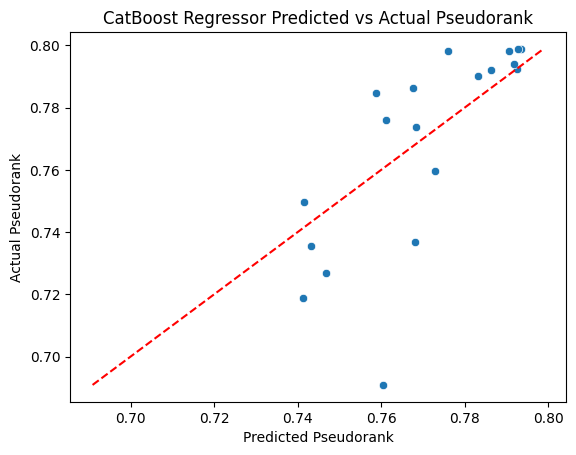

In [ ]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('CatBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [ ]:
MAE_dict = {'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Random Forest Regressor': RF.score(X_train_rank, y_train_rank), 'Gradient Boost Regressor': GB.score(X_train_rank, y_train_rank),
                 'XGBoost Regressor': XG.score(X_train_rank, y_train_rank), 'CatBoost Regressor': CB.score(X_train_rank, y_train_rank)}
summary_genes_rank = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_genes_rank

,MAE,MAPE,R²
Random Forest Regressor,0.016535,0.022109,0.932746
Gradient Boost Regressor,0.017312,0.023144,0.999974
XGBoost Regressor,0.016227,0.021817,0.999701
CatBoost Regressor,0.015455,0.020755,0.999999


####Summary of Model Screening

In [ ]:
summary_merged = pd.concat([summary_genes_score.add_prefix('genes_DE_'),
                            summary_genes_rank.add_prefix('genes_PR_')], axis=1)

summary_merged

,genes_DE_MAE,genes_DE_MAPE,genes_DE_R²,genes_PR_MAE,genes_PR_MAPE,genes_PR_R²,pathways_DE_MAE,pathways_DE_MAPE,pathways_DE_R²,pathways_PR_MAE,pathways_PR_MAPE,pathways_PR_R²
Random Forest Regressor,0.502607,0.220917,0.922504,0.016535,0.022109,0.932746,0.477658,0.215585,0.918061,0.020233,0.026956,0.885370
Gradient Boost Regressor,0.544240,0.233837,0.999945,0.017312,0.023144,0.999974,0.474108,0.216221,0.999623,0.019064,0.025477,0.999760
XGBoost Regressor,0.538127,0.229096,1.000000,0.016227,0.021817,0.999701,0.532262,0.230050,0.999999,0.021314,0.028511,0.999690
CatBoost Regressor,0.495887,0.217116,1.000000,0.015455,0.020755,0.999999,0.510991,0.230386,0.999998,0.019033,0.025454,0.999997


The above summary table has a lot of information, so I'll make a smaller tables for the MAE and MAPE to help with comparisons.  The R2 values are pretty consisttent accross learners, so we will leave those for now.

In [ ]:
summary_merged_MAE = summary_merged[['genes_DE_MAE', 'genes_PR_MAE']]
summary_merged_MAE

,genes_DE_MAE,genes_PR_MAE,pathways_DE_MAE,pathways_PR_MAE
Random Forest Regressor,0.502607,0.016535,0.477658,0.020233
Gradient Boost Regressor,0.544240,0.017312,0.474108,0.019064
XGBoost Regressor,0.538127,0.016227,0.532262,0.021314
CatBoost Regressor,0.495887,0.015455,0.510991,0.019033


From this summary of MAE, we learn the following:

1) MAE for PR predictions are way lower than for DE predictions.  This is partly due to the different scales between PR and DE, with DE being about 5x higher that PR, but the difference between MAE is closer to 20x.  We'll use MAPE to better compare predictions of PR and DE.
2) Best Learners: CatBoost, but it can vary by split.

Note: I ran the model screening with a few different splits by changing the ranndom state seed and the MAE differneces between best learners (excluding Multiple Regression) are smaller than the MAE diffences with the same learner working with different splits (more on this below).  CatBoost genes_PR_MAE varied from 0.022 to 0.009 with my tests.  Random Forest and CatBoost were usually the best, but not every time.

In [ ]:
summary_merged_MAPE = summary_merged[['genes_DE_MAPE', 'genes_PR_MAPE']]
summary_merged_MAPE

,genes_DE_MAPE,genes_PR_MAPE,pathways_DE_MAPE,pathways_PR_MAPE
Random Forest Regressor,0.220917,0.022109,0.215585,0.026956
Gradient Boost Regressor,0.233837,0.023144,0.216221,0.025477
XGBoost Regressor,0.229096,0.021817,0.230050,0.028511
CatBoost Regressor,0.217116,0.020755,0.230386,0.025454


From this summary of MAPE, we learn the following:

1) We confirm that predictions from PR are better than predictions from DE, as a percentage of the target values.  MAPE for DE is 5-10x higher than for PR.
2) Best Learners overall: Random Forest and CatBoost using genes to predict PR.

Another approach to evaluating these models is to see how their predictions rank the donors relative to the actual order.  The most plausible 'real world' application of this type of model would be to select the top 5-10 donors for for validation in the lab.  We will look at this in the next section.

##Assessing Donor Order

To visualize this donor ranking, I'll use a slope chart comparing actual donor order to the new order based on predictions using Random Forest and CatBoost predictions from gene datasets.

In [ ]:
donor_order_RF = pd.DataFrame({'actual_pr':y_test_rank,
                               'actual_de':y_test_score,
                               'pred_rank_genes':pd.Series(y_pred_RF_rank_genes, index=y_test_rank.index),
                               'pred_score_genes':pd.Series(y_pred_RF_score_genes, index=y_test_score.index)})
donor_order_CB = pd.DataFrame({'actual_pr':y_test_rank,
                               'actual_de':y_test_score,
                               'pred_rank_genes':pd.Series(y_pred_CB_rank_genes, index=y_test_rank.index),
                               'pred_score_genes':pd.Series(y_pred_CB_score_genes, index=y_test_score.index)})
donor_order_RF.head()

,actual_pr,actual_de,pred_rank_genes,pred_score_genes
juuy,0.759697,1.790761,0.772004,2.689698
pulk,0.726904,2.004846,0.750377,2.556422
guyj,0.718967,1.538316,0.740756,2.527970
iudw,0.736700,2.045526,0.762369,2.393493
quls,0.735551,2.809054,0.746375,3.034382


In [ ]:
donor_order_rank = pd.DataFrame({'actual_pr':y_test_rank,
                                 'pred_RF':pd.Series(y_pred_RF_rank_genes, index=y_test_rank.index),
                                 'pred_CB':pd.Series(y_pred_CB_rank_genes, index=y_test_rank.index)})
donor_order_score = pd.DataFrame({'actual_de':y_test_score,
                               'pred_RF':pd.Series(y_pred_RF_score_genes, index=y_test_score.index),
                               'pred_CB':pd.Series(y_pred_CB_score_genes, index=y_test_score.index)})
donor_order_rank.head()

,actual_pr,pred_RF,pred_CB
juuy,0.759697,0.772004,0.772855
pulk,0.726904,0.750377,0.746879
guyj,0.718967,0.740756,0.741309
iudw,0.736700,0.762369,0.768136
quls,0.735551,0.746375,0.743201


In [ ]:
def slope_chart(data, left_col, right_col, title):
  left=data[left_col].dropna()
  right=data[right_col].dropna()
  donors=data.dropna().index
  fig, ax = plt.subplots(figsize=(6,8))
  for donor in donors:
    ax.plot([0,1],[left.loc[donor], right.loc[donor]], marker='o', linewidth=1)
  ax.set_xticks([0,1])
  ax.set_xticklabels([left_col, right_col])
  ax.set_xlim(-0.1,1.1)
  ax.invert_yaxis()
  ax.set_ylabel('Rank')
  ax.set_title(title)
  plt.tight_layout()
  plt.show()

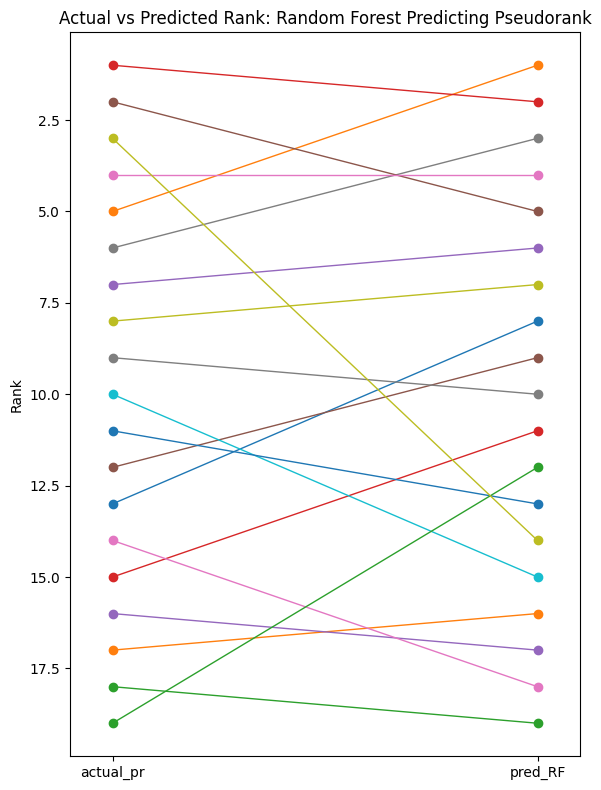

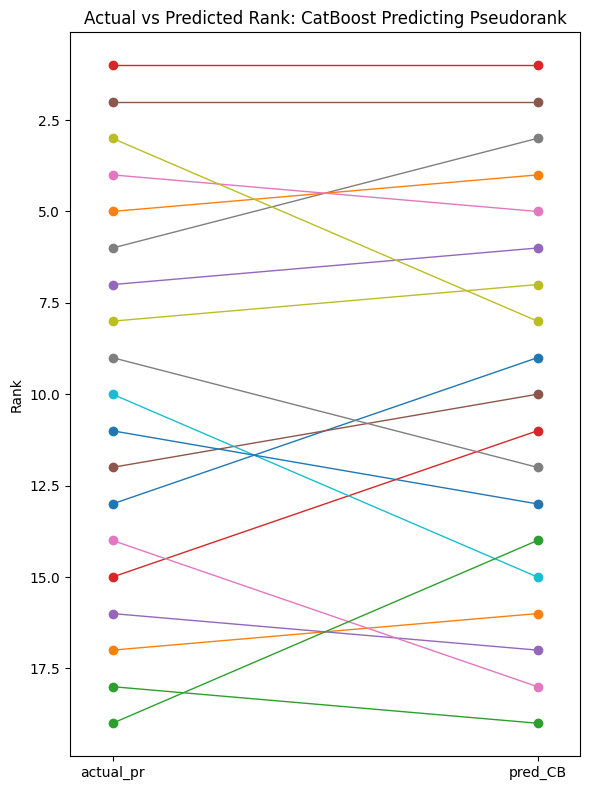

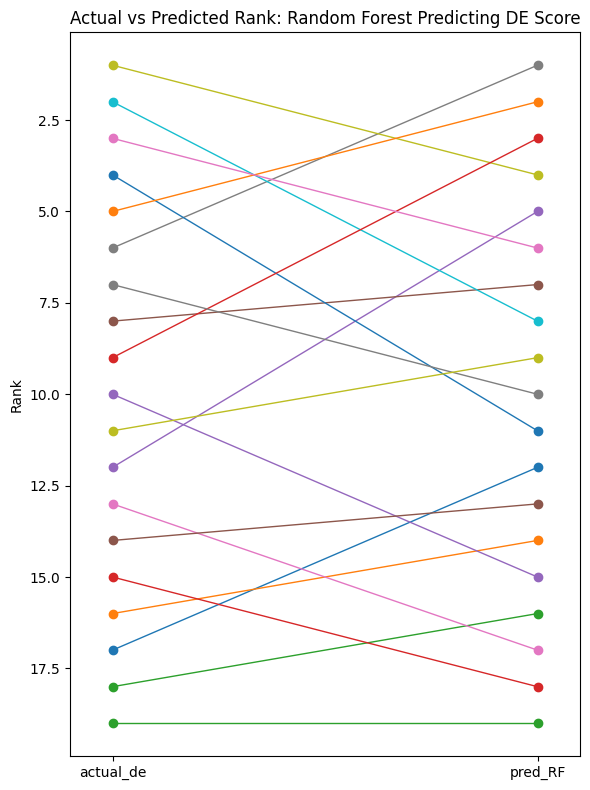

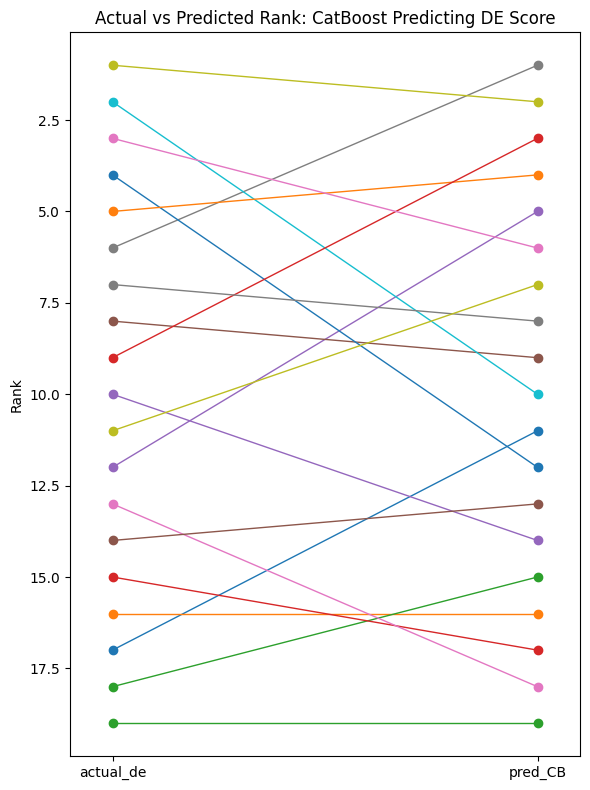

In [ ]:
rank_PR = donor_order_rank.rank(ascending=False)
rank_DE = donor_order_score.rank(ascending=False)

slope_chart(rank_PR, 'actual_pr', 'pred_RF', 'Actual vs Predicted Rank: Random Forest Predicting Pseudorank')
slope_chart(rank_PR, 'actual_pr', 'pred_CB', 'Actual vs Predicted Rank: CatBoost Predicting Pseudorank')
slope_chart(rank_DE, 'actual_de', 'pred_RF', 'Actual vs Predicted Rank: Random Forest Predicting DE Score')
slope_chart(rank_DE, 'actual_de', 'pred_CB', 'Actual vs Predicted Rank: CatBoost Predicting DE Score')

These look pretty good - all four are to pull out the best donors and get the correct order at the top of our list.  Next, I'll look at some statistical metrics of these ranking systems.

In [ ]:
def compare_ranks(data1, data2):
  spearman = spearmanr(data1, data2).statistic
  tau = kendalltau(data1, data2).statistic
  mean_rank_error = (data1 - data2).abs().mean()
  return spearman, tau, mean_rank_error

def top_five_overlap(data1, data2):
  top_five_actual = set(data1.nsmallest(5).index)
  top_five_predicted = set(data2.nsmallest(5).index)
  common = top_five_actual.intersection(top_five_predicted)
  return common

def top_three_overlap(data1, data2):
  top_three_actual = set(data1.nsmallest(3).index)
  top_three_predicted = set(data2.nsmallest(3).index)
  common = top_three_actual.intersection(top_three_predicted)
  return common

In [ ]:
print(top_five_overlap(rank_PR['actual_pr'], rank_PR['pred_RF']),
      top_five_overlap(rank_PR['actual_pr'], rank_PR['pred_CB']),
      top_five_overlap(rank_DE['actual_de'], rank_DE['pred_RF']),
      top_five_overlap(rank_DE['actual_de'], rank_DE['pred_CB']))

{'pahc', 'qunz', 'yelp', 'veku'} {'pahc', 'qunz', 'yelp', 'veku'} {'qunz', 'tolg'} {'qunz', 'tolg'}


In [ ]:
print(top_three_overlap(rank_PR['actual_pr'], rank_PR['pred_RF']),
      top_three_overlap(rank_PR['actual_pr'], rank_PR['pred_CB']),
      top_three_overlap(rank_DE['actual_de'], rank_DE['pred_RF']),
      top_three_overlap(rank_DE['actual_de'], rank_DE['pred_CB']))

{'yelp'} {'yelp', 'veku'} set() {'tolg'}


This tells us that the models predicting PR are able to find 4 of the top 5 donors correctly. Finding the top three is less reliable, but Catboost did a better job at this than Random Forest.  CatBoost predicitng PR found 2  of the top 3.  This suggests that models would succeed at getting the right donors selected for validation in the lab. Models predicting DE were less accurate.

In [ ]:
spearman, tau, mean_rank_error = compare_ranks(rank_PR['actual_pr'], rank_PR['pred_RF'])
print(f'Random Forest ranking of Psueodorank - Spearman: {spearman}')
print(f'Random Forest ranking of Psueodorank - Kendall Tau: {tau}')
print(f'Random Forest ranking of Psueodorank - Mean Rank Error: {mean_rank_error}')

Random Forest ranking of Psueodorank - Spearman: 0.7315789473684211
Random Forest ranking of Psueodorank - Kendall Tau: 0.5672514619883041
Random Forest ranking of Psueodorank - Mean Rank Error: 3.0526315789473686


In [ ]:
spearman, tau, mean_rank_error = compare_ranks(rank_PR['actual_pr'], rank_PR['pred_CB'])
print(f'CatBoost ranking of Psueodorank - Spearman: {spearman}')
print(f'CatBoost ranking of Psueodorank - Kendall Tau: {tau}')
print(f'CatBoost ranking of Psueodorank - Mean Rank Error: {mean_rank_error}')

CatBoost ranking of Psueodorank - Spearman: 0.863157894736842
CatBoost ranking of Psueodorank - Kendall Tau: 0.6725146198830408
CatBoost ranking of Psueodorank - Mean Rank Error: 2.3157894736842106


In [ ]:
spearman, tau, mean_rank_error = compare_ranks(rank_DE['actual_de'], rank_DE['pred_RF'])
print(f'Random Forest ranking of DE Score - Spearman: {spearman}')
print(f'Random Forest ranking of DE Score - Kendall Tau: {tau}')
print(f'Random Forest ranking of DE Score - Mean Rank Error: {mean_rank_error}')

Random Forest ranking of DE Score - Spearman: 0.719298245614035
Random Forest ranking of DE Score - Kendall Tau: 0.5087719298245613
Random Forest ranking of DE Score - Mean Rank Error: 3.5789473684210527


In [ ]:
spearman, tau, mean_rank_error = compare_ranks(rank_DE['actual_de'], rank_DE['pred_CB'])
print(f'CatBoost ranking of DE Score - Spearman: {spearman}')
print(f'CatBoost ranking of DE Score - Kendall Tau: {tau}')
print(f'CatBoost ranking of DE Score - Mean Rank Error: {mean_rank_error}')

CatBoost ranking of DE Score - Spearman: 0.6859649122807018
CatBoost ranking of DE Score - Kendall Tau: 0.47368421052631576
CatBoost ranking of DE Score - Mean Rank Error: 3.473684210526316


The above metrics look at the ranking over the entire test set, not just the top. Here again, the models predicting PR do better than models predicting DE. This also gives us the first clear distinction between the Random Forest and CatBoost learners predicting PR.  The Random Forest learners places donors an average of 3.2 ranks away from their actual rank, while the CatBoost learner places donros 2.3 ranks away from their actual rank.  Combined with the slightly lower MAE, this makes the CatBoost learner our selected model.

##Model Building: Final Steps

I the previous section, we selected the CatBoost learner, prediciting donor pseudorank as our preffered model.  We have selected hot to do Hyperparameter tuning as the risk of overfitting outweights the potential benefit of moderate improvements to the existing model.

As a final step, we will refine out features selection.  The existing model was made from the top 100 genes correlating with donor pseudorank. In the following we will optimize gene number, starting from the top 200 genes.

### With CB selection

Instead of selecting genes based on a linear correlation with pseudorank, it is better practice to select features using a tree based model.  Here we will use CatBoost Regressor to pick out the best genes in place of the dataset we created earlier and see if this improves our model.



In [ ]:
X = pd.DataFrame(donor_adata.X, columns=donor_adata.var_names, index=donor_adata.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train_pr, y_test_pr = train_test_split(X, y_pr, test_size=0.2, random_state=42)

In [ ]:
CB_full = CatBoostRegressor(verbose=0)
CB_full.fit(X_train, y_train_pr)
y_pred_full = CB_full.predict(X_test)

explainer = shap.TreeExplainer(CB_full)
shap_values = explainer.shap_values(X_train)

shap_importance = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(shap_importance, index=X_train.columns).sort_values(ascending=False)

In [ ]:
# Loop through features lists of the top 1 to 20 features to determine how many features are needed to maintain MAE in the CatBoost learner.
MAE_short = []
for i in range(1, 21, 1):
    X_train_short = X_train[shap_rank.index[:i]]
    X_test_short = X_test[shap_rank.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_short.append(mae_short)

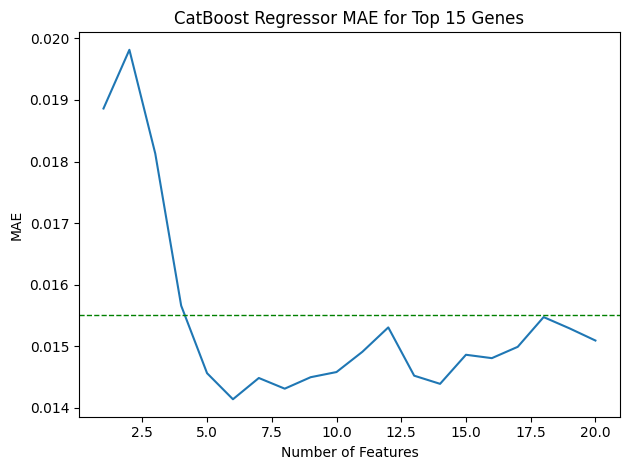

In [ ]:
features_short = range(1, 21, 1)
summary_short = pd.DataFrame({'MAE':MAE_short}, index=features_short)

sns.lineplot(data=summary_short, x=features_short, y='MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 15 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

The lowest MAE is 5-7 genes.  The error is consistently lower than we saw with our previous gene list (green dashed line; although I did have splits that got a lower error). Let's make a new dataset with the top 100 genes and do feature selection over multiple splits.

In [ ]:
shap_rank_100 = shap_rank[0:100]
donor_rank_100 = donor_adata[:, shap_rank_100.index]

###Feature Refinement Using Optimized Set of 100 genes

As the attempt with gene selection using a model to pick from the list of 11,000 was unsuccessful, we will go back to our gene lists based on correlation and try to further refine our feature selection.


In [ ]:
#Redo the split on this 'new' dataset
X = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train_pr, y_test_pr = train_test_split(X, y_pr, test_size=0.2, random_state=42)

In [ ]:
CB_100 = CatBoostRegressor(verbose=0)
CB_100.fit(X_train, y_train_pr)
y_pred_100 = CB_100.predict(X_test)
importances = CB_100.get_feature_importance() #Get feature importances
CB_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False) #Sort genes in order of importance

In [ ]:
# Loop through features lists of the top 20 features to determine how many features are needed to maintain MAE in the CatBoost learner.
MAE_short = []
for i in range(1, 21, 1):
    X_train_short = X_train[CB_importances.index[:i]]
    X_test_short = X_test[CB_importances.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_short.append(mae_short)

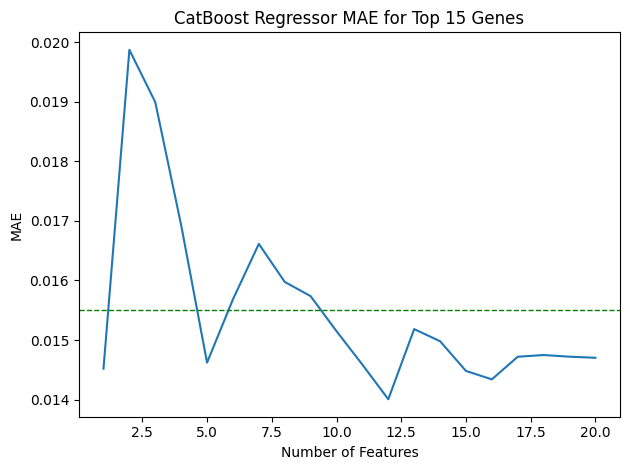

In [ ]:
features_short = range(1, 21, 1)
summary_short = pd.DataFrame({'MAE':MAE_short}, index=features_short)

sns.lineplot(data=summary_short, x=features_short, y='MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 15 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

With this split, the lowest error is with a model built on the top 11 genes.  Adding more genes leads to slight overfitting.

This is a surprisingly small number of genes.  Let's see how stable the error and the selected genes are over multiple splits.  We'll collect the MAE for each number of features on each split as well as the most important 6, 10 and 24 genes.

In [ ]:
n_splits = 20
top_6 = 6
top_10 = 10
top_24 = 24

selected_gene_6 = {}
selected_gene_10 = {}
selected_gene_24 = {}
mae_all = {}

for seed in range(n_splits):
  X_train, X_test, y_train, y_test = train_test_split(X, y_pr, test_size=0.2, random_state=seed) #Make Split
  full_model = CatBoostRegressor(verbose=0) #Fit full model
  full_model.fit(X_train, y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False) #Calculate importances
  mae_split = []
  for i in range(1, 31, 1):
    selected_features = importances_series.head(i).index #Select top k genes
    X_train_short = X_train[selected_features]
    X_test_short = X_test[selected_features]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split
  selected_gene_6[seed] = list(importances_series.head(top_6).index)
  selected_gene_10[seed] = list(importances_series.head(top_10).index)
  selected_gene_24[seed] = list(importances_series.head(top_24).index)

In [ ]:
mae_all_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_all_df.index = [f"split_{i+1}" for i in mae_all_df.index]
mae_all_df.columns = [f"{i+1}_genes" for i in range(30)]
mae_all_df

,1_genes,2_genes,3_genes,4_genes,5_genes,6_genes,7_genes,8_genes,9_genes,10_genes,...,21_genes,22_genes,23_genes,24_genes,25_genes,26_genes,27_genes,28_genes,29_genes,30_genes
split_1,0.025078,0.019251,0.017425,0.018508,0.017851,0.017330,0.017553,0.017277,0.018049,0.017551,...,0.016969,0.016652,0.017178,0.017078,0.017096,0.016483,0.017145,0.017299,0.016655,0.016969
split_2,0.021925,0.025291,0.019981,0.018857,0.018127,0.016847,0.016833,0.017435,0.016843,0.017123,...,0.014921,0.015467,0.015877,0.015288,0.015230,0.015319,0.015366,0.014848,0.015292,0.015552
split_3,0.021820,0.022019,0.022071,0.019917,0.018913,0.018124,0.017652,0.017952,0.017347,0.016817,...,0.017156,0.017106,0.017134,0.017198,0.016607,0.016528,0.017018,0.016915,0.017962,0.017030
split_4,0.016265,0.015802,0.014865,0.014785,0.014165,0.011559,0.011786,0.012246,0.011249,0.010650,...,0.008454,0.009702,0.009083,0.008518,0.009732,0.009304,0.009914,0.009262,0.009158,0.008966
split_5,0.022726,0.013942,0.012470,0.015146,0.012523,0.010997,0.011029,0.010490,0.011415,0.010434,...,0.009685,0.009704,0.009948,0.009315,0.009348,0.009919,0.009901,0.009814,0.009875,0.009662
split_6,0.021657,0.014573,0.014061,0.013585,0.012226,0.013584,0.011996,0.012793,0.014169,0.011754,...,0.011973,0.011540,0.011344,0.011880,0.010861,0.011370,0.011103,0.009603,0.010430,0.010150
split_7,0.016709,0.021009,0.019885,0.018019,0.018159,0.018737,0.017775,0.017466,0.017677,0.016498,...,0.017970,0.017614,0.016729,0.017972,0.017519,0.017746,0.017691,0.017520,0.017456,0.017611
split_8,0.029282,0.023945,0.021511,0.018402,0.016533,0.015808,0.016232,0.015066,0.013244,0.012334,...,0.013994,0.013810,0.014401,0.014559,0.014119,0.014453,0.014245,0.014495,0.013727,0.013548
split_9,0.020700,0.017713,0.013230,0.013212,0.009501,0.007862,0.008423,0.007768,0.008585,0.008220,...,0.008738,0.009120,0.008534,0.008601,0.008546,0.008600,0.008516,0.008197,0.008535,0.008964
split_10,0.021401,0.017059,0.016451,0.014460,0.013767,0.013465,0.013371,0.014383,0.013127,0.013284,...,0.012527,0.012856,0.012469,0.012076,0.012054,0.012615,0.012329,0.012193,0.012461,0.012656


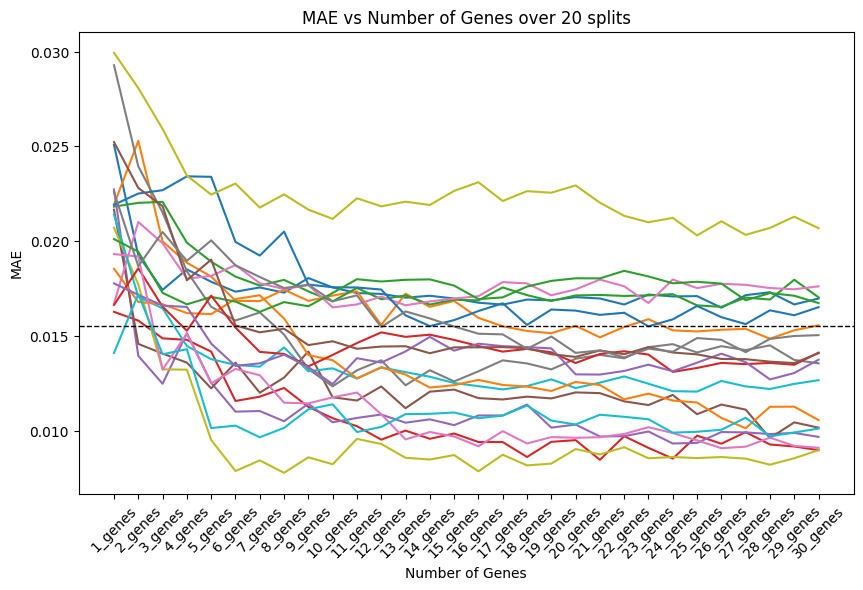

In [ ]:
plt.figure(figsize=(10, 6))
for idx, row in mae_all_df.iterrows():
  plt.plot(mae_all_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes over 20 splits')
plt.show()


We can see here that there is lots of variabilty between splits.  We can't get rid of the varibaility, but we can try to build a model that is as robust to this variability as possible.  First, let's look at the MAE for the average split.

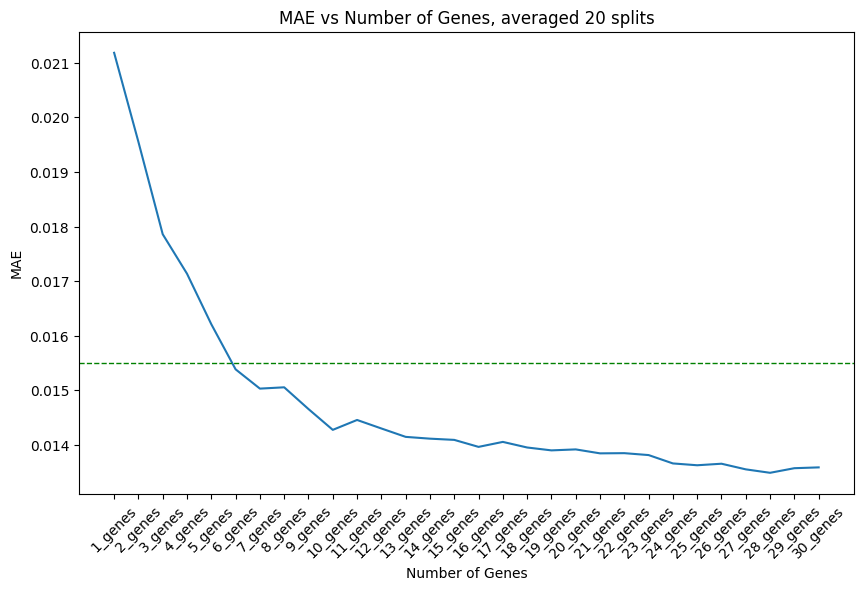

In [ ]:
mae_all_mean = mae_all_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_all_df.columns, mae_all_mean.values, label=idx)
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('MAE vs Number of Genes, averaged 20 splits')
plt.show()

Out mean MAE is lowest at 27 genes, but is acceptably low at as few as 9 genes.  Individual splits had the lowest MEA at 4 genes. This gives us some leeway - we don't have to get the number exact to have a reliable model.  This suggests that we have a fair amount of redundancy in our model - it might only take 20 genes to make predictions, but it's not always the same 20 genes. Not only that, the specific genes probably very from dataset to dataset, so picking a specific gene list might limit our ability to generalize this model.

To test this assumption, the next step is to see if the model picks the same genes with different splits.

In [ ]:
from collections import Counter
def count_gene_use(selected_gene_dict):
  all_genes = []
  for genes in selected_gene_dict.values():
    all_genes.extend(genes)
  gene_counts = Counter(all_genes)
  df = pd.DataFrame.from_dict(gene_counts, orient='index', columns=['count'])
  return df.sort_values(by='count', ascending=False)

In [ ]:
gene_counts_24_df = count_gene_use(selected_gene_24)
gene_counts_10_df = count_gene_use(selected_gene_10)
gene_counts_6_df = count_gene_use(selected_gene_6)

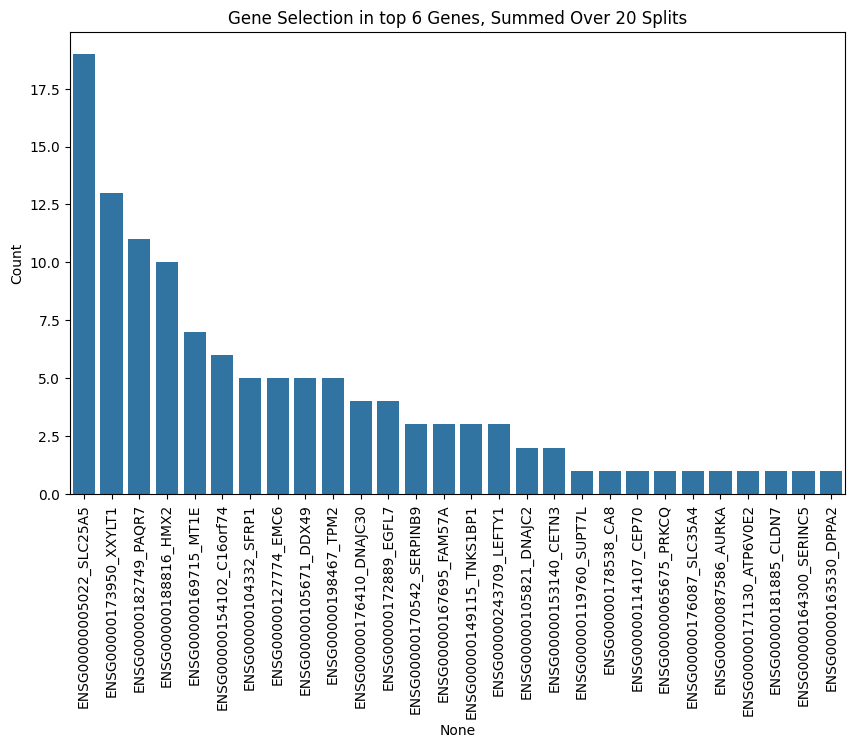

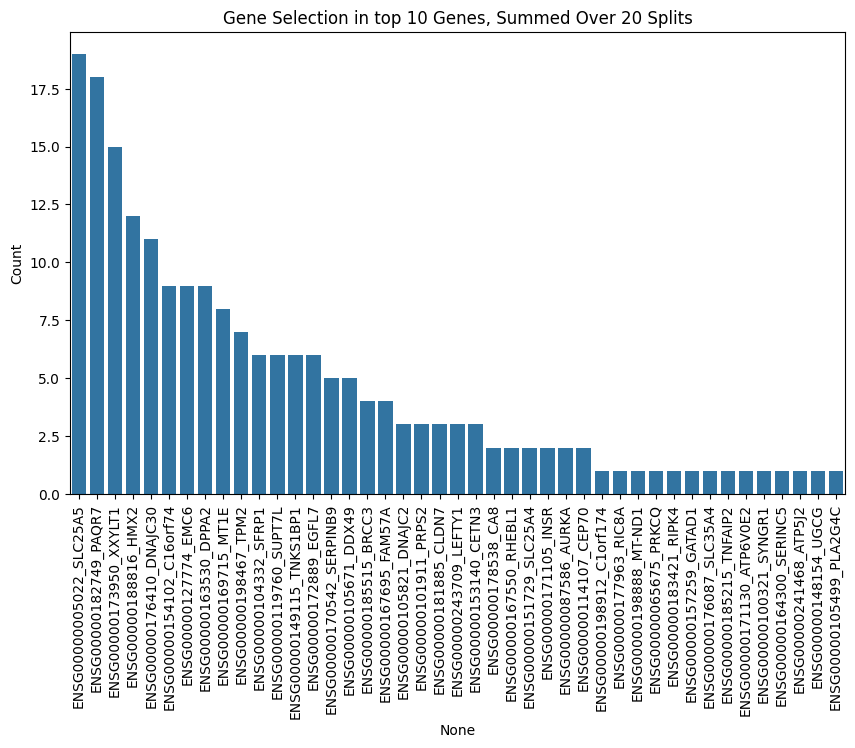

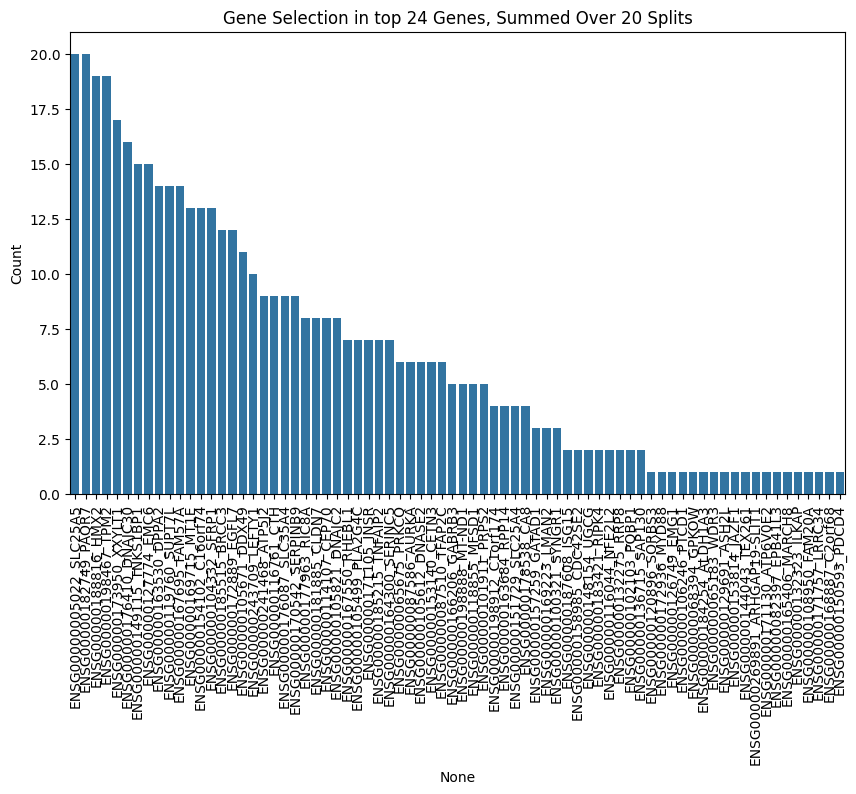

In [ ]:
for k, group in [(6, gene_counts_6_df), (10, gene_counts_10_df), (24, gene_counts_24_df)]:
  plt.figure(figsize=(10, 6))
  sns.barplot(data=group, x=group.index, y='count')
  plt.title(f"Gene Selection in top {k} Genes, Summed Over 20 Splits")
  plt.ylabel("Count")
  plt.xticks(rotation=90)
  plt.show()

In [ ]:
print(f'Number of genes in most important 24 genes over 20 splits: {gene_counts_24_df.shape[0]}')
print(f'Number of genes in most important 10 genes over 20 splits: {gene_counts_10_df.shape[0]}')
print(f'Number of genes in most important 6 genes over 20 splits: {gene_counts_6_df.shape[0]}')

Number of genes in most important 24 genes over 20 splits: 74
Number of genes in most important 10 genes over 20 splits: 43
Number of genes in most important 6 genes over 20 splits: 28


These results show us two things:

1) Out lists of 'top 6 genes' has 28 genes in it.  This confirms that there is redundancy in our model such that different sets of genes can be used to make predictions.
2) Some genes are more likely to be selected than others.  Some genes, like SLC25A5 are selected as being very important almost every time.  

Let's look at the overlap between the ~20 of genes most commonly in the top 24 and the genes in the top 10 or top 6.

In [ ]:
top_22 = gene_counts_24_df[gene_counts_24_df['count'] >= 9]
common_10 = list(set(gene_counts_10_df.index) & set(top_22.index))
common_6 = list(set(gene_counts_6_df.index) & set(top_22.index))
print(f'Number of genes with 9+ selections in most important 24 genes: {len(top_22)}')
print(f'Number of common genes also in top 10 most important genes: {len(common_10)}')
print(f'Number of common genes also in top 6 most important genes: {len(common_6)}')

Number of genes with 9+ selections in most important 24 genes: 22
Number of common genes also in top 10 most important genes: 21
Number of common genes also in top 6 most important genes: 19


There is clearly lots of overlap in the top 20 genes between splits.  We could make a model that uses just those genes, or we can make a model that picks it's own 20 genes based on that split.

### Comparing Maual or Automated Gene Selection

In this section, we will compare models build with a predetermined set of 22 genes (aka manual selection) or a model that selects up to 22 genes based on the split.

####Manual Gene Selection

In [ ]:
top_22genes = list(top_22.index)
top_22genes

['ENSG00000005022_SLC25A5',
 'ENSG00000182749_PAQR7',
 'ENSG00000188816_HMX2',
 'ENSG00000198467_TPM2',
 'ENSG00000173950_XXYLT1',
 'ENSG00000176410_DNAJC30',
 'ENSG00000149115_TNKS1BP1',
 'ENSG00000127774_EMC6',
 'ENSG00000163530_DPPA2',
 'ENSG00000119760_SUPT7L',
 'ENSG00000167695_FAM57A',
 'ENSG00000169715_MT1E',
 'ENSG00000154102_C16orf74',
 'ENSG00000104332_SFRP1',
 'ENSG00000185515_BRCC3',
 'ENSG00000172889_EGFL7',
 'ENSG00000105671_DDX49',
 'ENSG00000243709_LEFTY1',
 'ENSG00000241468_ATP5J2',
 'ENSG00000116761_CTH',
 'ENSG00000176087_SLC35A4',
 'ENSG00000170542_SERPINB9']

In [ ]:
#Remake the dataset with the top 22 genes for safety
donor_rank_22 = donor_adata[:, top_22genes].copy()

In [ ]:
n_splits = 20
mae_all = {}
importances_dict = {}
X_22 = pd.DataFrame(donor_rank_22.X, columns=donor_rank_22.var_names, index=donor_rank_22.obs_names)
y_pr = donor_adata.obs['pseudorank']

for seed in range(n_splits):
  X_train, X_test, y_train, y_test = train_test_split(X_22, y_pr, test_size=0.2, random_state=seed) #Make Split
  full_model = CatBoostRegressor(verbose=0) #Fit full model
  full_model.fit(X_train, y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
  importances_dict[seed] = pd.Series(100 * importances / importances.sum(), index=X_train.columns).sort_values(ascending=False)
  mae_split = []
  for i in range(1, 23, 1):
    selected_features = importances_series.head(i).index #Select top k genes
    X_train_short = X_train[selected_features]
    X_test_short = X_test[selected_features]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split

In [ ]:
mae_22_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_22_df.index = [f"split_{i+1}" for i in mae_22_df.index]
mae_22_df.columns = [f"{i+1}_genes" for i in range(22)]

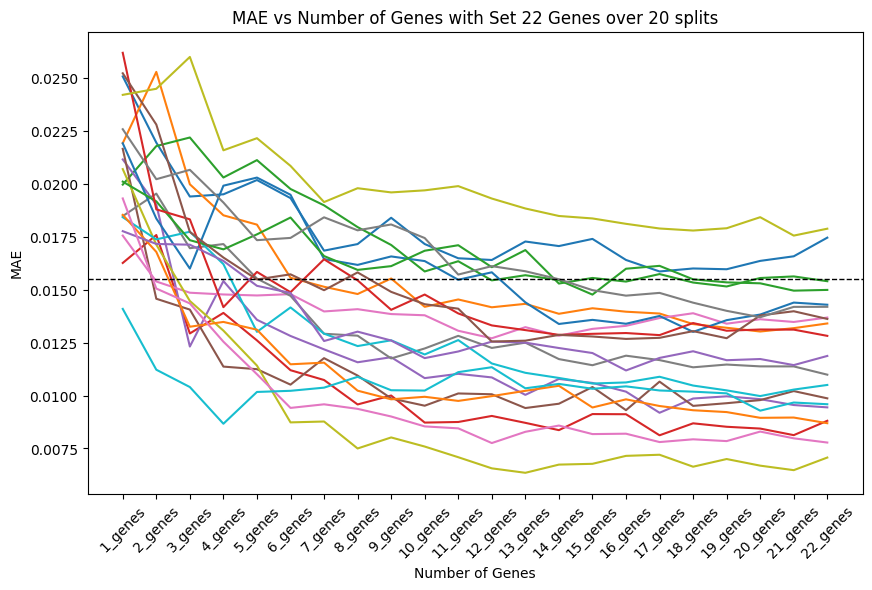

In [ ]:
plt.figure(figsize=(10, 6))
for idx, row in mae_22_df.iterrows():
  plt.plot(mae_22_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes with Set 22 Genes over 20 splits')
plt.show()


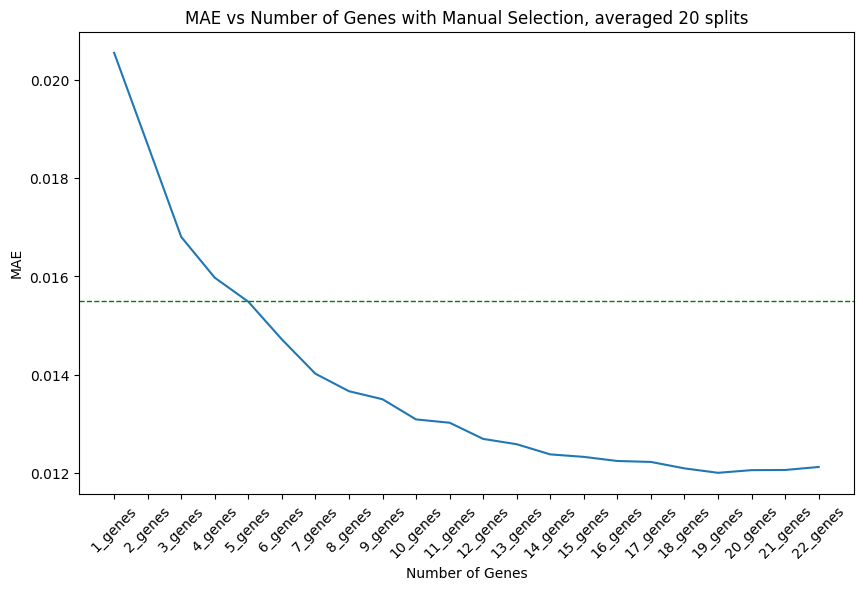

In [ ]:
mae_22_mean = mae_22_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_22_df.columns, mae_22_mean.values, label=idx)
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('MAE vs Number of Genes with Manual Selection, averaged 20 splits')
plt.show()

We can also look at the relative importance of each gene, averaged over the 20 splits.

In [ ]:
importances_df = pd.DataFrame.from_dict(importances_dict)
importances_df_mean = importances_df.mean(axis=1).sort_values(ascending=False)
importances_df_mean


,0
Unnamed: 0,
ENSG00000005022_SLC25A5,10.677369
ENSG00000176410_DNAJC30,6.156343
ENSG00000154102_C16orf74,6.094147
ENSG00000127774_EMC6,5.946591
ENSG00000172889_EGFL7,5.858165
ENSG00000188816_HMX2,5.558307
ENSG00000182749_PAQR7,5.536196
ENSG00000105671_DDX49,5.290932
ENSG00000149115_TNKS1BP1,4.948534


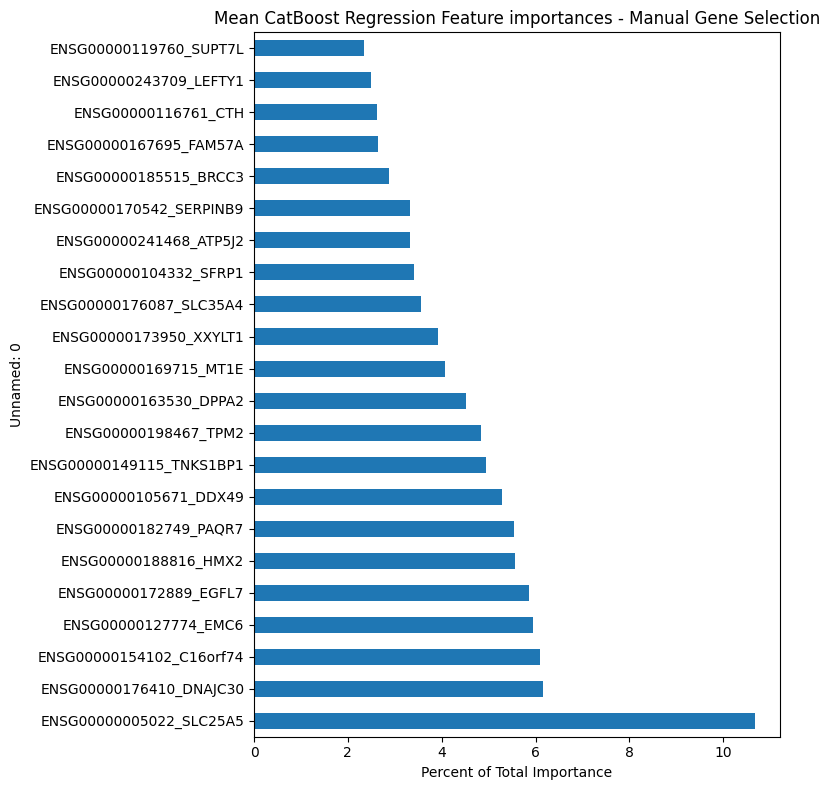

In [ ]:
#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_df_mean.plot.barh(ax=ax)
ax.set_title("Mean CatBoost Regression Feature importances - Manual Gene Selection")
ax.set_xlabel("Percent of Total Importance")
fig.tight_layout()
plt.show()

####Automated Gene Selection

Now let's try again with setting the model to pick any 22 genes from out list of 100.

In [ ]:
n_splits = 20
shap_threshold = .0005
mae_all = {}
importances_dict = {}
X_100 = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']

for seed in range(n_splits):
  X_train, X_test, y_train, y_test = train_test_split(X_100, y_pr, test_size=0.2, random_state=seed) #Make Split
  train_pool = Pool(X_train, y_train)
  selector_model = CatBoostRegressor(loss_function = 'MAE', verbose=0) #Fit full model
  selector_model.fit(X_train, y_train)
  shap_values = selector_model.get_feature_importance(data=train_pool, type='ShapValues') #Calculate shap values
  feature_importance = np.abs(shap_values).mean(axis=0) #Calculate feature importance
  sorted_features = sorted(zip(X_train.columns, feature_importance), key=lambda x: x[1], reverse=True)
  selected_genes = [f for f,val in zip(X_train.columns, feature_importance) if val > shap_threshold] #fine genes above threshold
  selected_genes = selected_genes[:22]
  if len(selected_genes) == 0:
    selected_genes = [f for f, _ in sorted_features[:5]]
  importances_dict[seed] = sorted_features[:22]
  mae_split = []
  for i in range(1, 23, 1):
    selected_features_short = selected_genes[:i] #Select top k genes
    X_train_short = X_train[selected_features_short]
    X_test_short = X_test[selected_features_short]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split

In [ ]:
mae_auto_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_auto_df.index = [f"split_{i+1}" for i in mae_auto_df.index]
mae_auto_df.columns = [f"{i+1}_genes" for i in range(22)]

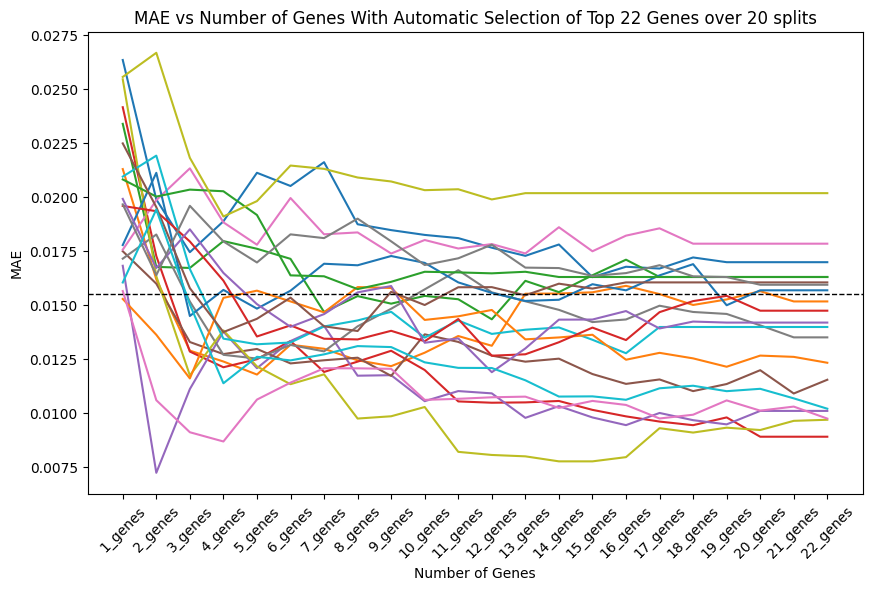

In [ ]:
plt.figure(figsize=(10, 6))
for idx, row in mae_auto_df.iterrows():
  plt.plot(mae_auto_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes With Automatic Selection of Top 22 Genes over 20 splits')
plt.show()


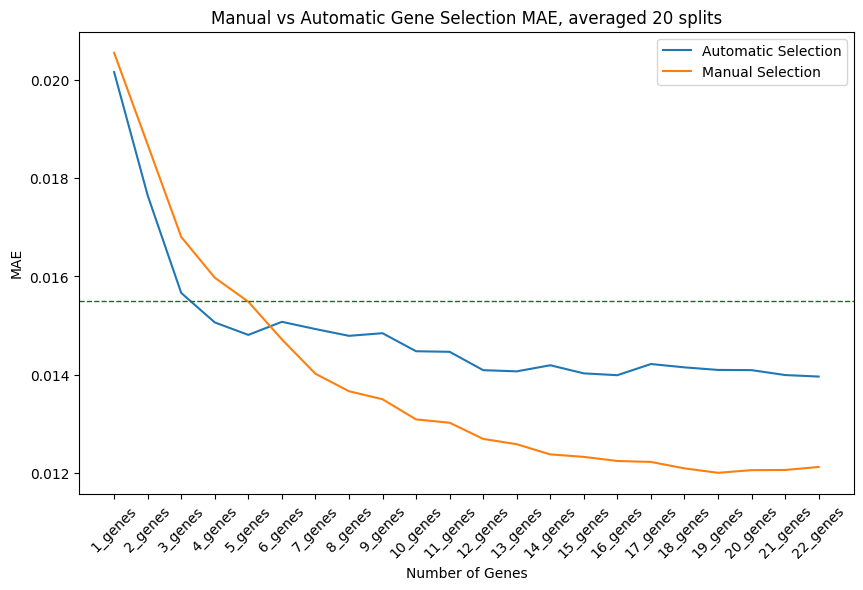

In [ ]:
mae_22_mean = mae_22_df.mean(axis=0)
mae_auto_mean = mae_auto_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_auto_df.columns, mae_auto_mean.values, label='Automatic Selection')
plt.plot(mae_22_df.columns, mae_22_mean.values, label='Manual Selection')
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('Manual vs Automatic Gene Selection MAE, averaged 20 splits')
plt.legend()
plt.show()

In [ ]:
importances_df_auto = pd.DataFrame.from_dict(importances_dict)
importances_df_auto_mean = importances_df.mean(axis=1).sort_values(ascending=False)

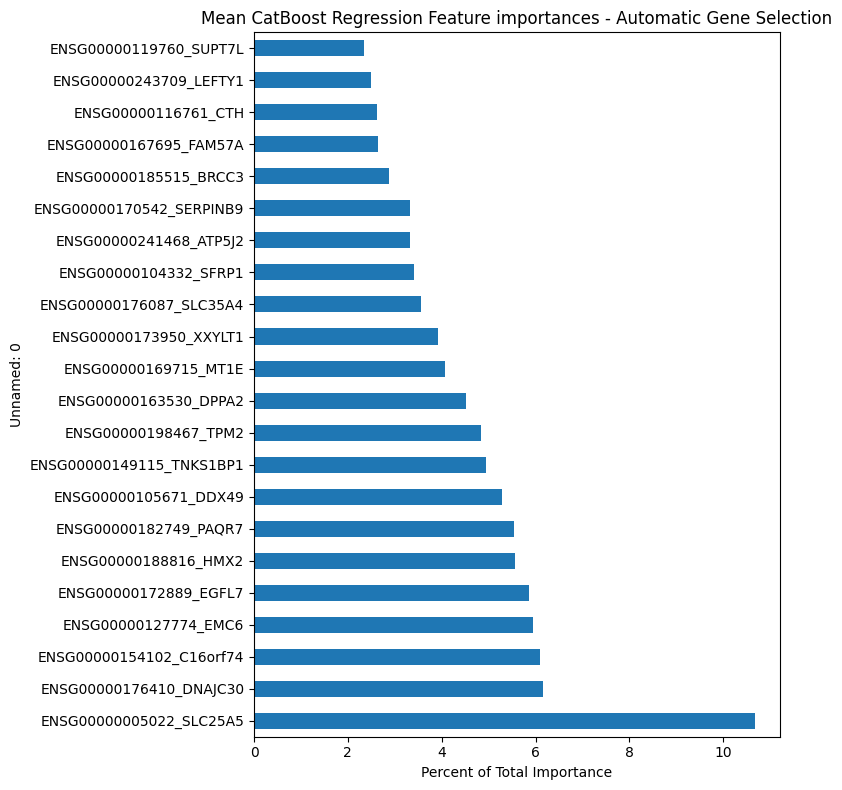

In [ ]:
#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_df_auto_mean.plot.barh(ax=ax)
ax.set_title("Mean CatBoost Regression Feature importances - Automatic Gene Selection")
ax.set_xlabel("Percent of Total Importance")
fig.tight_layout()
plt.show()

This comparison between manually selecting specific genes and letting the model automatically select genes for each split shows us that we get a lower error when we manually choose the genes if we use 7 or more genes.  If we wanted to use fewer than 7 genes, the automatic selection is superior.

This does not mean that manual gene selection makes the best model for new data.  New data will be from different RNAseq batches and might get better predictions from a different set of genes than what we used here.  Without testing this on new datasets, using manual selection in our final model is risky.  I recommend making a model that is based on our 22 genes, and a model able to do gene selction based on the specifics of the new dataset.

##Final Model

In our final model, we must build something that will be as reslient as possible to differences between new datasets, even if that means sacrificing MAE with the existing dataset.  For that reason, I will use recursive feature elimination to select genes based on the split, rather than using the genes we have already identified for our split with random state 42.

In [ ]:
#Final Model with Manual Gene Selection
X_22 = pd.DataFrame(donor_rank_22.X, columns=donor_rank_22.var_names, index=donor_rank_22.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train, y_test = train_test_split(X_22, y_pr, test_size=0.2, random_state=seed)
CB_final_manual = CatBoostRegressor(verbose=0)
CB_final_manual.fit(X_train, y_train)
y_pred_manual = CB_final_manual.predict(X_test)
mae_manual = mean_absolute_error(y_test, y_pred_manual )

In [ ]:
X_100 = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']
shap_threshold = .0005

X_train, X_test, y_train, y_test = train_test_split(X_100, y_pr, test_size=0.2, random_state=seed) #Perform Split

train_pool = Pool(X_train, y_train)
selector_model = CatBoostRegressor(loss_function = 'MAE', verbose=0) #Build Selector Model for calculating Shap Values
selector_model.fit(X_train, y_train)
shap_values = selector_model.get_feature_importance(data=train_pool, type='ShapValues') #Calculate shap values
feature_importance = np.abs(shap_values).mean(axis=0) #Calculate feature importance
sorted_features = sorted(zip(X_train.columns, feature_importance), key=lambda x: x[1], reverse=True)
selected_genes = [f for f,val in zip(X_train.columns, feature_importance) if val > shap_threshold] #fine genes above threshold
selected_genes = selected_genes[:22]
if len(selected_genes) == 0:
  selected_genes = [f for f, _ in sorted_features[:5]]
CB_final_auto = CatBoostRegressor(loss_function = 'MAE', verbose=0) #train new model on selected_genes
CB_final_auto.fit(X_train[selected_genes], y_train)
y_pred_auto = CB_final_auto.predict(X_test[selected_genes])
mae_auto = mean_absolute_error(y_test, y_pred_auto)

In [ ]:
print(f'MAE for Manual Gene Selection: {mae_manual}')
print(f'MAE for Automatic Gene Selection: {mae_auto}')

MAE for Manual Gene Selection: 0.0099860100793652
MAE for Automatic Gene Selection: 0.010170355417938088


In [ ]:
#Save final dataset used for manual and automatic models
donor_rank_100.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/donor_100_automatic.h5ad")
donor_rank_22.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/donor_22_manual.h5ad")

In [ ]:
CB_final_manual.save_model("/content/drive/MyDrive/Springboard/Capstone3_iPSC/CB_final_manual.cbm")
CB_final_auto.save_model("/content/drive/MyDrive/Springboard/Capstone3_iPSC/CB_final_automatic.cbm")